# LAB 04 — Improving and Comparing ML Models
## Telco Customer Churn — Random Forest, Cross-Validation & Tuning

## Student Information
**Name:** Faryal Gul

**Student ID:** 023-24-0014

**Section:** B

**GitHub:**

**Kaggle:**

**Dataset:** Telco Customer Churn (Kaggle)

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, EDA, and Decision Trees. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [2]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Decision Tree Baseline

Before improving anything, re-establish your Lab 3 Decision Tree result as the benchmark for this lab.

*Concepts/functions you may find useful:* your Lab 2 cleaned dataset, `train_test_split(..., stratify=y)`, `DecisionTreeClassifier(max_depth=...)`

**Tasks**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same `random_state`).
2. Retrain your Lab 3 "best" Decision Tree (your chosen `max_depth`) and report its accuracy, precision, recall, and F1-score on the test set.

In [3]:
# Task 1 — re-load cleaned dataset, recreate X/y and train/test split
df=pd.read_csv("clean_churn.csv")
y=df["Churn"].map({"No":0,"Yes":1})
x=df.drop(columns="Churn")
x=pd.get_dummies(x,drop_first=True)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)


In [4]:
# Task 2 — retrain Lab 3 Decision Tree, report test-set metrics
model=DecisionTreeClassifier(max_depth=8,random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred)*100)
print("Precision:",precision_score(y_test,y_pred)*100)
print("Recall:",recall_score(y_test,y_pred)*100)
print("F1:",f1_score(y_test,y_pred)*100)

Accuracy: 79.31526390870185
Precision: 63.10679611650486
Recall: 52.56064690026954
F1: 57.35294117647059


**Task 2 — Decision Tree Baseline Metrics**

| Metric | Value |
|---|-------|
| Accuracy | 79.31 |
| Precision | 63.10 |
| Recall | 52.56 |
| F1-score | 57.35 |

---

## 2. Random Forest

A Random Forest trains many Decision Trees on bootstrapped samples and averages their predictions.

*Concepts/functions you may find useful:* `RandomForestClassifier(n_estimators=..., random_state=...)`, `.fit()`, `.predict()`

**Tasks**
3. Train a `RandomForestClassifier` on the same training data (reasonable default `n_estimators`, e.g. 100–300; fix `random_state`). Generate predictions on the test set.
4. In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

In [5]:
# Task 3 — train Random Forest, predict on test set
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)

**Answer 4:**
Random Forest can generalize better than a single unrestricted Decision Tree because it uses multiple Decision Trees that provide different predictions. By combining their predictions, Random Forest produces a more robust and reliable prediction.

## 3. Model Evaluation

Evaluate the Random Forest the same rigorous way you evaluated the Decision Tree in Lab 3.

*Concepts/functions you may find useful:* `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Task**
5. Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

Accuracy: 78.9586305278174
Precision: 63.66906474820144
Recall: 47.7088948787062
F1 score: 54.54545454545454


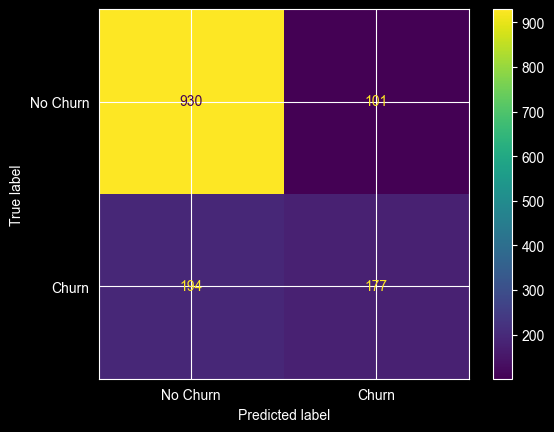

In [6]:
# Task 5 — Random Forest metrics + confusion matrix
accuracy=accuracy_score(y_test,rf_pred)*100
precision=precision_score(y_test,rf_pred)*100
recall=recall_score(y_test,rf_pred)*100
f1=f1_score(y_test,rf_pred)*100
print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 score:",f1)
cm=confusion_matrix(y_test,rf_pred)
disp=ConfusionMatrixDisplay( confusion_matrix=cm,display_labels=["No Churn","Churn"])
disp.plot()
plt.show()

**Task 5 — Random Forest Metrics**

| Metric | Value  |
|---|--------|
| Accuracy | 78.95% |
| Precision | 63.66% |
| Recall | 47.70% |
| F1-score | 54.54% |

**Observation (confusion matrix):**
The correctly caught churners are 177 and missed churners are 194

---

## 4. Decision Tree vs Random Forest

Place both models side by side.

**Tasks**
6. Build a single comparison table: Decision Tree (Section 1) vs. Random Forest (Section 3), across all four metrics.
7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

**Task 6 — Comparison Table**

| Metric | Decision Tree | Random Forest |
|---|---------------|---------------|
| Accuracy | 79.31%        | 78.95%        |
| Precision | 63.10%        | 63.66%        |
| Recall | 52.56%        | 47.70%        |
| F1-score | 57.35%        | 54.54%        |

**Answer 7:**
The Decision Tree performs better overall than the Random Forest. The Decision Tree has higher accuracy, recall, and F1-score, while the Random Forest has slightly higher precision. The differences are mostly small, but the Decision Tree performs noticeably better in recall and F1-score. Since the dataset has class imbalance, recall and F1-score are important for evaluating churn prediction. Therefore, the Decision Tree performs better overall based on these results.

## 5. Cross-Validation

A single train/test split gives one noisy estimate of performance. k-fold cross-validation trains and tests the model k times on different splits.

*Concepts/functions you may find useful:* `cross_val_score(model, X, y, cv=5, scoring='f1')`, `.mean()`, `.std()`

**Tasks**
8. Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.
9. How do the cross-validated results compare to your single train/test split results from Section 4? Do they change your view of which model is better, or how confident you are in that conclusion?

In [8]:
# Task 8 — 5-fold cross-validation for both models
model_cv_score=cross_val_score(model,x,y,cv=5,scoring='f1')
print("Decision tree F1 score : ",model_cv_score)
print("Decision tree Mean F1 score : ",model_cv_score.mean())
print("Decision tree standard deviation F1 score : ",model_cv_score.std())
rf_cv_score=cross_val_score(rf,x,y,cv=5,scoring='f1')
print("Random Forest F1 score : ",rf_cv_score)
print("Random Forest Mean F1 score : ",rf_cv_score.mean())
print("Random Forest standard deviation F1 score : ",rf_cv_score.std())

Decision tree F1 score :  [0.56901408 0.5497076  0.5352518  0.56515373 0.57142857]
Decision tree Mean F1 score :  0.5581111580728993
Decision tree standard deviation F1 score :  0.013703979266036304
Random Forest F1 score :  [0.54769231 0.55417957 0.50903614 0.55451713 0.55538695]
Random Forest Mean F1 score :  0.5441624205429203
Random Forest standard deviation F1 score :  0.017775650370834256


**Task 8 — Cross-Validation Results**

| Model | Mean F1 | Std F1 |
|---|---------|--------|
| Decision Tree | 0.55    | 0.013  |
| Random Forest | 0.54    | 0.017  |

**Answer 9:**
**Observation:**
The Decision Tree performs slightly better than the Random Forest in 5-fold cross-validation. Its mean F1-score is 0.5581 compared with 0.5442 for the Random Forest. The difference is relatively small, but the Decision Tree also has a lower standard deviation (0.0137 vs. 0.0178), indicating that its F1-score is more consistent across the folds. Therefore, the Decision Tree shows slightly better and more consistent performance in cross-validation.


---

## 6. Hyperparameter Tuning

Search over a small grid of hyperparameters to see whether a tuned model meaningfully beats your default-settings baseline. Keep the search small — this is about the workflow, not an exhaustive search.

*Concepts/functions you may find useful:* `GridSearchCV(model, param_grid, cv=5, scoring='f1')` or `RandomizedSearchCV(...)`, `.best_params_`, `.best_score_`, `.best_estimator_`

**Tasks**
10. Choose 2–3 Random Forest hyperparameters to tune (e.g. `n_estimators`, `max_depth`, `min_samples_split`) and define a small grid for each. Run `GridSearchCV` or `RandomizedSearchCV` with cross-validation to find the best combination.
11. Report the best hyperparameters found and the corresponding cross-validated score.
12. Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [13]:
# Task 10 — define a small param grid and run GridSearchCV / RandomizedSearchCV
param_grid = {
    # YOUR CODE HERE
    "n_estimators" : [50,100,150],
    "max_depth" : [5,8,10],
    "min_samples_split" : [2,5,10],
}
grid_search=GridSearchCV(RandomForestClassifier(random_state=42),param_grid=param_grid,cv=5,scoring='f1')
grid_search.fit(x_train,y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 8, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

**Answer 11 (best hyperparameters & CV score):**
_(your answer here)_

In [14]:
# Task 12 — evaluate the tuned model on the test set
print("Best parameters ",grid_search.best_params_)
print("Best score ",grid_search.best_score_)
tuned_rf=grid_search.best_estimator_
tuned_rf.fit(x_train,y_train)
tuned_rf_predict=tuned_rf.predict(x_test)
print("Accuracy of tuned Random Forest : ",accuracy_score(y_test,tuned_rf_predict)*100)
print("Precision of tuned Random Forest :",precision_score(y_test,tuned_rf_predict)*100)
print("Recall of tuned Random Forest :",recall_score(y_test,tuned_rf_predict)*100)
print("F1 of tuned Random Forest :",f1_score(y_test,tuned_rf_predict)*100)

Best parameters  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Best score  0.571821943706187
Accuracy of tuned Random Forest :  80.09985734664765
Precision of tuned Random Forest : 66.19718309859155
Recall of tuned Random Forest : 50.673854447439346
F1 of tuned Random Forest : 57.404580152671755


**Task 12 — Tuned Random Forest Metrics**

| Metric | Value  |
|---|--------|
| Accuracy | 80.09% |
| Precision | 66.19% |
| Recall | 50.67% |
| F1-score | 57.40% |

---

## 7. Final Model Comparison

Bring every model you've built into one table.

**Task**
13. Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

**Task 13 — Final Comparison Table**

| Metric | Decision Tree | Random Forest (default) | Random Forest (tuned) |
|---|---------------|-------------------------|-----------------------|
| Accuracy | 79.31%        | 78.95%                  | 80.09%                |
| Precision | 63.10%        | 63.66%                  | 66.19%                |
| Recall | 52.56%        | 47.70%                  | 50.67%                |
| F1-score | 57.35%        | 54.54%                  | 57.40%                |

## 8. Feature Importance

Look inside your best-performing model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
14. Extract and visualize `feature_importances_` for your best model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

TotalCharges                             0.177439
tenure                                   0.176495
MonthlyCharges                           0.127008
InternetService_Fiber optic              0.065908
PaymentMethod_Electronic check           0.058177
Contract_Two year                        0.055464
OnlineSecurity_Yes                       0.033248
Contract_One year                        0.031574
TechSupport_Yes                          0.027258
PaperlessBilling_Yes                     0.022401
TechSupport_No internet service          0.016732
SeniorCitizen                            0.016287
OnlineBackup_Yes                         0.016109
MultipleLines_Yes                        0.015693
gender_Male                              0.015629
Partner_Yes                              0.013756
Dependents_Yes                           0.013553
DeviceProtection_Yes                     0.012892
OnlineBackup_No internet service         0.012864
StreamingTV_No internet service          0.012782


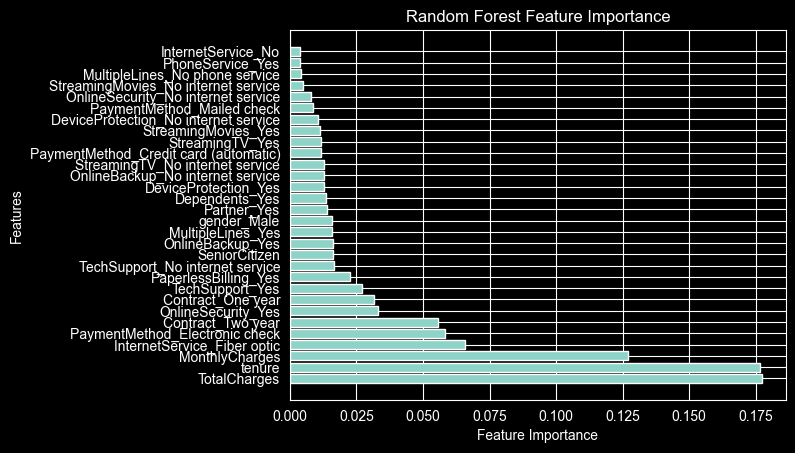

In [16]:
# Task 14 — extract and visualize feature importances
feature_importance=pd.Series( tuned_rf.feature_importances_,index=x.columns).sort_values(ascending=False)
print(feature_importance)
plt.barh(feature_importance.index,feature_importance.values)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()

**Answer 14:**
The five most important features are TotalCharges, tenure, MonthlyCharges, InternetService_Fiber optic, and PaymentMethod_Electronic check. TotalCharges has the highest feature importance (0.1774), followed by tenure (0.1765) and MonthlyCharges (0.1270). These results mostly agree with the observations from Lab 2's EDA. In Lab 2, we observed that churned customers generally had lower tenure and higher MonthlyCharges, and electronic check had a relatively high churn rate. These features are also among the important features learned by the Random Forest. TotalCharges was not one of the main features highlighted in our Lab 2 observations, but it emerged as the most important feature in the Random Forest.


---

## 9. Final Model Selection

Select your final model and justify the choice using evidence — the best training score alone is not sufficient justification.

**Task**
15. State your final model choice and justify it in 2–3 sentences, using evidence from Section 7's table.

**Answer 15:**
I would choose the Tuned Random Forest as the final model. It has the highest accuracy (80.09%), precision (66.19%), and F1-score (57.40%) among the three models. Although its recall is slightly lower than the Decision Tree, the Tuned Random Forest performs better overall based on the test-set results.

---

## 10. Kaggle Prediction/Submission

Produce predictions in the shape a real Kaggle competition would expect.

**Task**
16. Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted `Churn` column. Save it as `submission.csv`.

In [23]:
# Task 16 — build and save the submission file
# submission = pd.DataFrame({'customerID': ..., 'Churn': ...})
# submission.to_csv('submission.csv', index=False)
original_df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
test_ids = original_df.loc[x_test.index, "customerID"]
tuned_rf_pred=tuned_rf.predict(x_test)
predicted_churn=pd.Series(tuned_rf_pred).map({
    0: "No",
    1: "Yes"
})
submission=pd.DataFrame({
    "customerID": test_ids.values,
    "Churn": predicted_churn.values
})
submission.to_csv("submission.csv", index=False)
print(submission.head())
print(submission.shape)



   customerID Churn
0  4018-PPNDW    No
1  3859-CVCET    No
2  5883-GTGVD    No
3  5696-CEIQJ    No
4  2546-KZAAT   Yes
(1402, 2)


---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
17. Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?
18. What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

**Answer 17 — Conclusion:**
I chose the Tuned Random Forest as my final model. It achieved the highest accuracy (80.09%), precision (66.19%), and F1-score (57.40%) compared with the Decision Tree from Lab 3 and the default Random Forest. Its recall was slightly lower than the Decision Tree, but its overall performance was better based on the test-set results. One limitation is that the model still has a relatively low recall, so it may miss some customers who will churn. The class imbalance in the dataset is also a limitation.

**Answer 18 — Next steps:**
If I had more time, I would try different machine learning algorithms and tune their hyperparameters further. I would also handle the class imbalance directly, for example by using class weights or other balancing techniques. This could help improve recall and identify more customers who are likely to churn.


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset)
- [ ] Section 1 — Decision Tree Baseline
- [ ] Section 2 — Random Forest
- [ ] Section 3 — Model Evaluation
- [ ] Section 4 — Decision Tree vs Random Forest
- [ ] Section 5 — Cross-Validation
- [ ] Section 6 — Hyperparameter Tuning
- [ ] Section 7 — Final Model Comparison
- [ ] Section 8 — Feature Importance
- [ ] Section 9 — Final Model Selection (justified)
- [ ] Section 10 — Kaggle Prediction/Submission (submission.csv produced)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted